# Energy-Distance Analysis for Molecular Interactions

Publication-quality visualization of interaction energies vs. intermolecular distances for different spin configurations and interaction types.

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Publication-quality settings
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'text.usetex': False,
    'mathtext.default': 'regular',
    'axes.linewidth': 1.0,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'grid.linewidth': 0.5
})

In [47]:
ref_energy = -6227.1749

# Publication-quality color palette (colorblind-friendly)
configurations = {
    'config1': {'phi1': 196, 'phi2': 16, 'zeta': 0.000000, 'color': '#d62728', 'marker': '.'},
    'config2': {'phi1': 0, 'phi2': 0, 'zeta': 1.210625, 'color': '#ff7f0e', 'marker': '.'},
    'config3': {'phi1': 9, 'phi2': 5, 'zeta': 0.55875, 'color': '#2ca02c', 'marker': '.'},
    'config4': {'phi1': 0, 'phi2': 0, 'zeta': 0.000000, 'color': '#1f77b4', 'marker': '.'}
}

for config_name, config in configurations.items():
    phi1, phi2, zeta = config['phi1'], config['phi2'], config['zeta']
    config['label'] = f"φ={phi1}, χ={phi1 + phi2}, ζ={zeta:.1f}"

# Plot parameters
gray_points_color = "#00000000"
point_size_gray = 8
point_size_config = 25
line_width = 1.5
sampling_interval = 10
figure_size = (3.5, 2.8)
x_range = (8, 11)
y_range = (-1.5, 0)

In [43]:
def load_data_file(filepath):
    try:
        data = pd.read_csv(filepath, sep=r'\s+', header=None, comment='#')
        data.columns = ['phi1', 'phi2', 'zeta', 'distance', 'energy']
        return data
    except:
        print(f"Error loading {filepath}")
        return None

ropt_data = load_data_file("../E_Ropt_SS.dat")
all_data = load_data_file("../E_all_SS.dat")

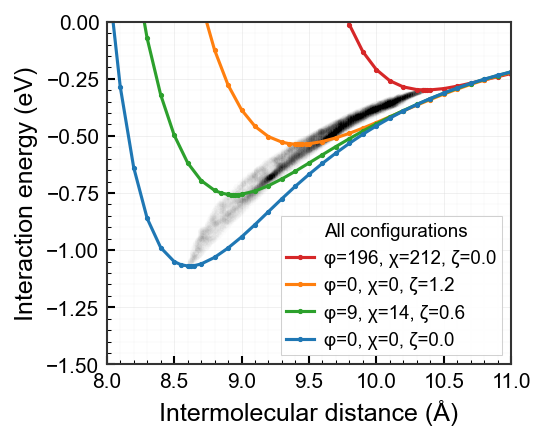

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=figure_size)

if ropt_data is not None and all_data is not None:
    # Plot gray background points (optimized for publication)
    ropt_sampled = ropt_data.iloc[::sampling_interval].copy()
    ropt_sampled['energy_normalized'] = ropt_sampled['energy'] - 2*ref_energy
    ax.scatter(ropt_sampled['distance'], ropt_sampled['energy_normalized'], 
              c=gray_points_color, s=point_size_gray, alpha=0.009, 
              label='All configurations', zorder=1, edgecolors='none')
    
    # Plot specific configurations
    for config_name, config in configurations.items():
        phi1, phi2, zeta = config['phi1'], config['phi2'], config['zeta']
        mask = (all_data['phi1'] == phi1) & (all_data['phi2'] == phi2) & (np.abs(all_data['zeta'] - zeta) < 1e-6)
        config_data = all_data[mask].copy()
        
        if len(config_data) > 0:
            config_data['energy_normalized'] = config_data['energy'] - 2*ref_energy
            config_data = config_data.sort_values('distance')
            ax.plot(config_data['distance'], config_data['energy_normalized'],
                   color=config['color'], linewidth=line_width, 
                   marker=config['marker'], markersize=4, markeredgewidth=0.5,
                   label=config['label'], zorder=2)

# Professional styling
ax.set_xlim(x_range)
ax.set_ylim(y_range)
ax.set_xlabel('Intermolecular distance (Å)')
ax.set_ylabel('Interaction energy (eV)')
# ax.set_title('SS Interaction', fontsize=11, pad=10)

# Professional grid and ticks
ax.tick_params(axis='both', which='major', labelsize=10, width=1.0, length=4)
ax.tick_params(axis='both', which='minor', width=0.5, length=2)
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.xaxis.set_major_locator(MaxNLocator(6))  # Limit number of major ticks
ax.yaxis.set_major_locator(MaxNLocator(6))

# Subtle grid
ax.grid(True, which='major', linewidth=0.3, color='#DDDDDD', alpha=0.7)
ax.grid(True, which='minor', linewidth=0.2, color='#DDDDDD', alpha=0.4)
ax.set_axisbelow(True)
ax.tick_params(direction='in', which='both')

# Professional legend
legend = ax.legend(loc='lower right', frameon=True, fancybox=False, 
                  shadow=False, fontsize=9, borderpad=0.3, 
                  handlelength=1.5, handletextpad=0.5, columnspacing=1)
legend.get_frame().set_linewidth(0.5)
legend.get_frame().set_edgecolor('#CCCCCC')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Clean borders
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('#333333')

plt.tight_layout(pad=0.2)

# Publication-quality outputs
# plt.savefig("figure1_SS_interactions.png", dpi=600, bbox_inches='tight', 
#            facecolor='white', edgecolor='none', pad_inches=0.05)
# plt.savefig("figure1_SS_interactions.pdf", bbox_inches='tight', 
#            facecolor='white', edgecolor='none', pad_inches=0.05)
# plt.savefig("figure1_SS_interactions.eps", bbox_inches='tight', 
#            facecolor='white', edgecolor='none', pad_inches=0.05)

plt.show()

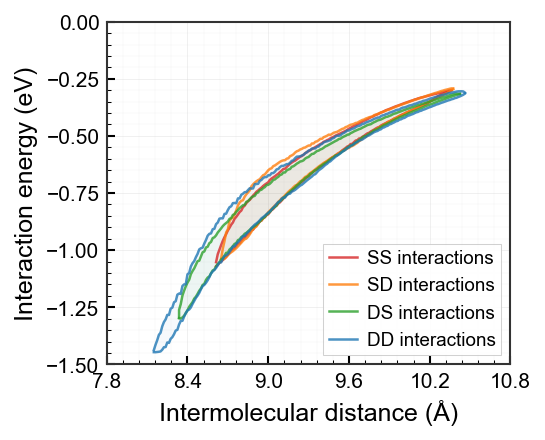

In [41]:
fig2, ax2 = plt.subplots(1, 1, figsize=figure_size)

minmax_files = {
    'SS': 'E_Ropt_minmax_SS.dat',
    'SD': 'E_Ropt_minmax_SD.dat',
    'DS': 'E_Ropt_minmax_DS.dat', 
    'DD': 'E_Ropt_minmax_DD.dat'
}

minmax_colors = {
    'SS': '#d62728',
    'SD': '#ff7f0e',
    'DS': '#2ca02c',
    'DD': '#1f77b4'
}

minmax_labels = {
    'SS': 'SS interactions',
    'SD': 'SD interactions', 
    'DS': 'DS interactions',
    'DD': 'DD interactions'
}

# Load and plot min/max data for each interaction type
for interaction_type, filename in minmax_files.items():
    try:
        data = pd.read_csv(filename, sep=r'\s+', header=None, 
                          names=['distance', 'E_min', 'E_max'])
        data['E_min_normalized'] = data['E_min'] - 2*ref_energy  
        data['E_max_normalized'] = data['E_max'] - 2*ref_energy
        
        # Create filled area between min and max
        ax2.fill_between(data['distance'], data['E_min_normalized'], 
                        data['E_max_normalized'], 
                        alpha=0.04, color=minmax_colors[interaction_type], 
                        linewidth=0)
        
        # Add boundary lines for clarity
        ax2.plot(data['distance'], data['E_min_normalized'], 
                color=minmax_colors[interaction_type], linewidth=1.2, alpha=0.8)
        ax2.plot(data['distance'], data['E_max_normalized'], 
                color=minmax_colors[interaction_type], linewidth=1.2, alpha=0.8, label=minmax_labels[interaction_type])
                
    except FileNotFoundError:
        print(f"Warning: {filename} not found")

# Professional styling for second plot
ax2.set_xlim([7.8, 10.8])
ax2.set_ylim([-1.5, 0])
ax2.set_xlabel('Intermolecular distance (Å)')
ax2.set_ylabel('Interaction energy (eV)')

# ax2.set_title('Optimum distance-all interaction', fontsize=11, pad=8)

# Professional grid and ticks
ax2.tick_params(axis='both', which='major', labelsize=10, width=1.0, length=4)
ax2.tick_params(axis='both', which='minor', width=0.5, length=2)
ax2.xaxis.set_minor_locator(AutoMinorLocator(5))
ax2.yaxis.set_minor_locator(AutoMinorLocator(5))
ax2.xaxis.set_major_locator(MaxNLocator(6))
ax2.yaxis.set_major_locator(MaxNLocator(6))

# Subtle grid
ax2.grid(True, which='major', linewidth=0.3, color='#DDDDDD', alpha=0.7)
ax2.grid(True, which='minor', linewidth=0.2, color='#DDDDDD', alpha=0.4)
ax2.set_axisbelow(True)
ax2.tick_params(direction='in', which='both')

# Professional legend
legend2 = ax2.legend(loc='lower right', frameon=True, fancybox=False, 
                    shadow=False, fontsize=9, borderpad=0.3, 
                    handlelength=1.5, handletextpad=0.5, columnspacing=1)
legend2.get_frame().set_linewidth(0.5)
legend2.get_frame().set_edgecolor('#CCCCCC')
legend2.get_frame().set_facecolor('white')
legend2.get_frame().set_alpha(0.9)

# Clean borders
for spine in ax2.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('#333333')

plt.tight_layout(pad=0.2)

# Publication-quality outputs
# plt.savefig("figure2_energy_ranges.png", dpi=600, bbox_inches='tight', 
#            facecolor='white', edgecolor='none', pad_inches=0.05)
# plt.savefig("figure2_energy_ranges.pdf", bbox_inches='tight', 
#            facecolor='white', edgecolor='none', pad_inches=0.05)
# plt.savefig("figure2_energy_ranges.eps", bbox_inches='tight', 
#            facecolor='white', edgecolor='none', pad_inches=0.05)

plt.show()